In [1]:
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_v2 import *

/home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/qiskit_dynamics/dispatch/backends/jax.py:34: UserWarning: The functionality in the perturbation module of Qiskit Dynamics requires a JAX version <= 0.4.6, due to a bug in JAX versions > 0.4.6. For versions 0.4.4, 0.4.5, and 0.4.6, using the perturbation module functionality requires setting os.environ['JAX_JIT_PJIT_API_MERGE'] = '0' before importing JAX or Dynamics.
  warnings.warn(


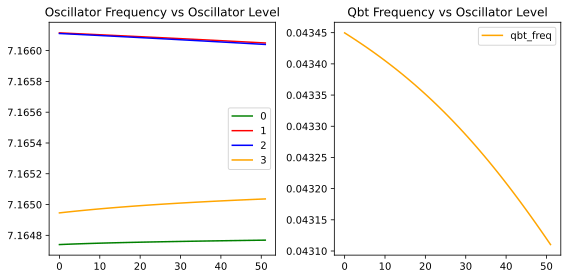

In [42]:
def plot_frequencies_qbt_osc(dressed_ener: Callable, ols):
    colors = ['green', 'red', 'blue', 'orange']

    # Create a figure and a set of subplots
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # Adjusted for better spacing

    # Second subplot for oscillator frequencies
    for ql in [0, 1, 2, 3]:
        osc_energies = []
        for ol in range(0, ols - 8):
            osc_energies.append(dressed_ener(ql, ol + 1) - dressed_ener(ql, ol))
        axs[0].plot(list(range(ols - 8)), osc_energies, label=f'{ql}', color=colors[ql])
    axs[0].set_title('Oscillator Frequency vs Oscillator Level')
    axs[0].legend()



    qbt_energies = []
    for ol in range(ols-8):
        qbt_energies.append(dressed_ener(2, ol) - dressed_ener(1, ol))
    axs[1].plot(list(range(ols-8)), qbt_energies, label=f'qbt_freq', color=colors[ql])
    axs[1].set_title('Qbt Frequency vs Oscillator Level')
    axs[1].legend()

    # Show the plots
    plt.tight_layout()  # Adjust the layout to make room for the legend
    plt.show()
    
    
ql = 20
max_ol = 60

system = FluxoniumOscillatorSystem(
    computaional_states = '1,2',
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677 ,
    qubit_level = ql,
    osc_level = max_ol,
    g_strength = 0.18,
    products_to_keep=[[ql,ol] for ql in [0,1,2,3] for ol in range(max_ol)] 
    )


energies=  system.hilbertspace.eigenvals(system.qbt.truncated_dim * system.osc.truncated_dim )


def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]


ols = system.osc.truncated_dim

plot_frequencies_qbt_osc(dressed_ener, ols)

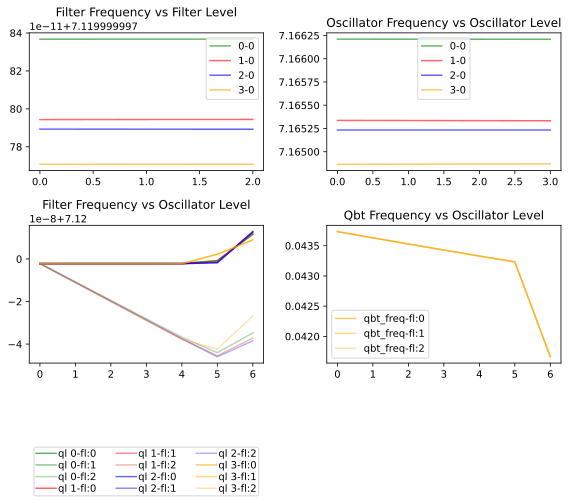

In [93]:

def plot_frequencies(dressed_ener: Callable, ols, fls):
    colors = ['green', 'red', 'blue', 'orange']

    # Create a figure and a set of subplots
    fig, axs = plt.subplots(2, 2, figsize=(8, 8))  # Adjusted for better spacing

    # First subplot for filter frequencies
    for ql in [0, 1, 2, 3]:
        filter_energies = [[] for _ in range(ols)]
        for ol in [0]:
            for fl in range(fls-1):
                filter_energies[ol].append(dressed_ener(ql, ol, fl+1) - dressed_ener(ql, ol, fl))
            axs[0,0].plot(list(range(fls-1)), filter_energies[ol], label=f'{ql}-{ol}', color=colors[ql], alpha=(1 - (ol) / ols) * 0.6)
    axs[0,0].set_title('Filter Frequency vs Filter Level')
    axs[0,0].legend()

    # Second subplot for oscillator frequencies
    for ql in [0, 1, 2, 3]:
        osc_energies = [[] for _ in range(fls)]
        for fl in [0]:
            for ol in range(0, ols - 3):
                osc_energies[fl].append(dressed_ener(ql, ol + 1, fl) - dressed_ener(ql, ol, fl))
            axs[0,1].plot(list(range(ols - 3)), osc_energies[fl], label=f'{ql}-{fl}', color=colors[ql], alpha=(1 - (fl) / fls) * 0.6)
    axs[0,1].set_title('Oscillator Frequency vs Oscillator Level')
    axs[0,1].legend()


    for ql in [0, 1, 2, 3]:
        filter_energies = [[] for _ in range(fls)]
        for fl in range(fls - 1):
            for ol in range( ols):
                filter_energies[fl].append(dressed_ener(ql, ol, fl+1) - dressed_ener(ql, ol, fl))
            axs[1,0].plot(list(range(ols)), filter_energies[fl], label=f'ql {ql}-fl:{fl}', color=colors[ql], alpha=(1 - (fl) / fls) * 0.6)
    axs[1,0].set_title('Filter Frequency vs Oscillator Level')
    axs[1,0].legend(
            loc='lower center', 
            bbox_to_anchor=(0.5, -1), 
            ncol=3, 
            frameon=True, 
            borderpad=0.2,  # Padding inside the border, smaller value = tighter packing
            handletextpad=0.2,  # Padding between the legend handle and text
            labelspacing=0.2   # Vertical spacing between the labels
        )


    qbt_energies = [[] for _ in range(fls)]
    for fl in [0,1,2]:
        for ol in range(ols):
            qbt_energies[fl].append(dressed_ener(2, ol, fl) - dressed_ener(1, ol, fl))
        axs[1,1].plot(list(range(ols)), qbt_energies[fl], label=f'qbt_freq-fl:{fl}', color=colors[ql], alpha=(1 - (fl) / fls) * 0.6)
    axs[1,1].set_title('Qbt Frequency vs Oscillator Level')
    axs[1,1].legend()

    # Show the plots
    plt.tight_layout()  # Adjust the layout to make room for the legend
    plt.show()

    
system = FluxoniumOscillatorFilterSystem(
    computaional_states = '1,2',
    # Er = 7.16518677 ,
    # Er = 7.16518677 ,
    Ef = 7.12,
    qubit_level = 5,
    osc_level = 7,
    filter_level=4,
    g_strength = 0.18,
    G_strength = 0.00001
    )
energies=  system.hilbertspace.eigenvals(system.qbt.truncated_dim * system.osc.truncated_dim  * system.filter.truncated_dim)


def dressed_ener(ql,ol,fl):
    return energies[system.product_to_dressed[(ql,ol,fl)]]


ols = system.osc.truncated_dim
fls = system.filter.truncated_dim

plot_frequencies(dressed_ener, ols, fls)

In [86]:
tlist = np.linspace(0,100,100)
results = system.run_mesolve_parrallel(
    initial_states=[ system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(4)],
    tlist = tlist,
    drive_terms=[
        DriveTerm(
            driven_op=system.a_trunc + system.a_trunc.dag(),
            # driven_op=system.b_trunc + system.b_trunc.dag(),
            pulse_shape_func=square_pulse_with_rise_fall,
            pulse_shape_args={
                'w_d': 7.1716,
                'amp': 0.002,
                't_square': 10000
            }
        )],
    e_ops=[
            system.b_trunc,
            system.b_trunc.dag()*system.b_trunc,
            system.a_trunc,
            system.a_trunc.dag()*system.a_trunc
        ],
)

 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/multiprocessing/popen_fork.py: 66

 *********96%********** ] Elapsed 5.23s / Remaining 00:00:00:000[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00 [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00 [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          1%           ] Elapsed 0.03s / Remaining 00:00:00:02[          1%           ] Elapsed 0.03s / Remaining 00:00:00:03[          1%           ] Elapsed 0.03s / Remaining 00:00:00:03[          1%           ] Elapsed 0.04s / Remaining 00:00:00:03[          2%           ] Elapsed 0.07s / Remaining 00:00:00:03 [          2%           ] Elapsed 0.07s / Remaining 00:00:00:03[          2%           ] Elapsed 0.07s / Remaining 00:00:00:03[*         3%           ] Elapsed 0.12s / Remaining 00:00:00:03  [*         3%           ] Elapsed 0.12s / Remaining 00:00:00:03[*         3%           ] Elapsed 0.12s / Remaining 00:00:00:03[*         3%           ] Elapsed 0.14s / Remaining 00:00:00:04[*         4%           ] Elapsed 0.18s / Remaini

Processing states with pad_back_custom: 100%|██████████| 100/100 [00:00<00:00, 3985.01it/s]


 [*********98%***********] Elapsed 5.27s / Remaining 00:00:00:00[*********97%********** ] Elapsed 5.29s / Remaining 00:00:00:00[*********99%***********] Elapsed 5.31s / Remaining 00:00:00:00Total run time:   5.31s


Processing states with pad_back_custom:   0%|          | 0/100 [00:00<?, ?it/s]

 [*********98%***********] Elapsed 5.33s / Remaining 00:00:00:00

Processing states with pad_back_custom: 100%|██████████| 100/100 [00:00<00:00, 3853.75it/s]


 [*********99%***********] Elapsed 5.38s / Remaining 00:00:00:00Total run time:   5.38s


Processing states with pad_back_custom: 100%|██████████| 100/100 [00:00<00:00, 4009.74it/s]


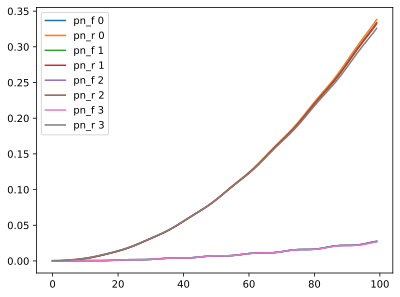

In [87]:
for i in [0,1,2,3]:
    plt.plot(results[i].expect[1],label = f"pn_f {i}")
    plt.plot(results[i].expect[3],label = f"pn_r {i}")
plt.legend()

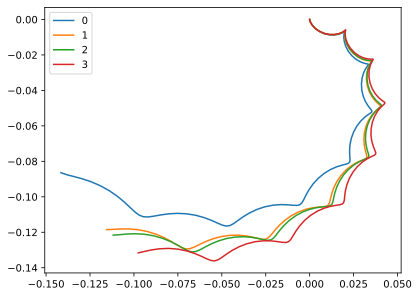

In [88]:
first_dominant_freq =find_dominant_frequency(results[0].expect[0],tlist)
for i in [0,1,2,3]:
    alpha = results[i].expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    real = alpha.real
    imag = alpha.imag
    plt.plot(-imag, real, label = f'{i}')
plt.legend()

 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook.py: 1699ComplexWarning: Casting complex values to real discards the imaginary part
 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook.py: 1345

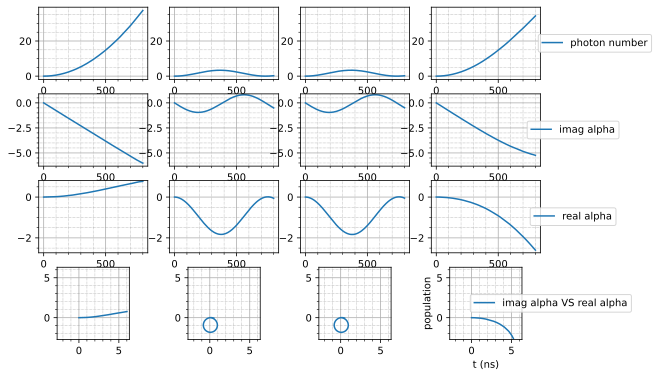

In [25]:
ql = 20
max_ol = 60

system = FluxoniumOscillatorSystem(
    computaional_states = '1,2',
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677 ,
    qubit_level = ql,
    osc_level = max_ol,
    g_strength = 0.18,
    products_to_keep=[[ql,ol] for ql in [0,1,2,3] for ol in range(max_ol)] 
    )
tlist = np.linspace(0,800,800)
results = system.run_mesolve_parrallel(
    initial_states=[ system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(4)],
    tlist = tlist,
    drive_terms=[
        DriveTerm(
            driven_op=system.a_trunc + system.a_trunc.dag(),
            pulse_shape_func=square_pulse_with_rise_fall,
            pulse_shape_args={
                'w_d': 7.16475,
                'amp': 0.0025,
                't_square': 10000
            }
        )],
    e_ops=[
            system.a_trunc,
            system.a_trunc.dag()*system.a_trunc
        ],
)



plot_population(results=results,
                qubit_level=ql,
                osc_level=max_ol,
                product_to_dressed=system.product_to_dressed,
                a=system.a,
                w_d=5,
                tlist=results[0].times,
                fourier=1,
                plot_only_pn_alpha=True
                )

 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook.py: 1699ComplexWarning: Casting complex values to real discards the imaginary part
 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook.py: 1345

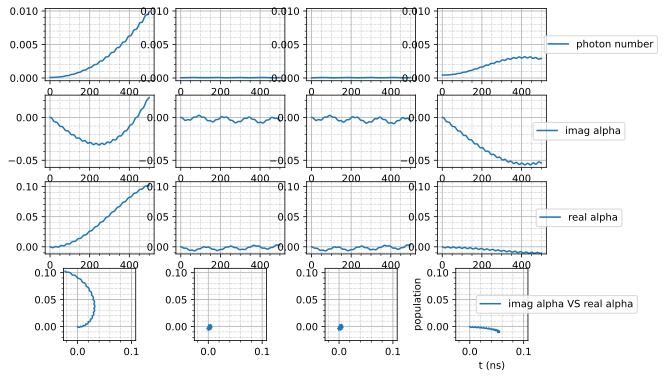

In [20]:

# results = []
# for i in range(4):
#     result = run_jax_solve(
#         w_d = 7.16475,
#         static_hamiltonian= system.diag_dressed_hamiltonian ,  
#         initial_state = system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) , 
#         tlist = tlist,
#         c_ops = None,
#         mode = 'gpu',
#         amp = 0.00425,
#         driven_operator = system.a_trunc + system.a_trunc.dag(),
#         chunk_size = 0.5
#         )
#     results.append(result)



plot_population(results=results,
                qubit_level=ql,
                osc_level=max_ol,
                product_to_dressed=system.product_to_dressed,
                a=system.a_trunc,
                w_d=5,
                tlist=results[0].times,
                fourier=1,
                plot_only_pn_alpha=True
                )